<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/30_Impulse_Response_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Observations: 240
Simulation VAR(1) eigenvalue magnitudes: [0.7  0.25]

ADF stationarity diagnostics (H0: unit root)
variable1: ADF=-6.685, p-value=4.242e-09
variable2: ADF=-6.180, p-value=6.502e-08


/tmp/ipykernel_2933/2798063610.py:35: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *_ = adfuller(df[col], autolag='AIC')
/tmp/ipykernel_2933/2798063610.py:35: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *_ = adfuller(df[col], autolag='AIC')


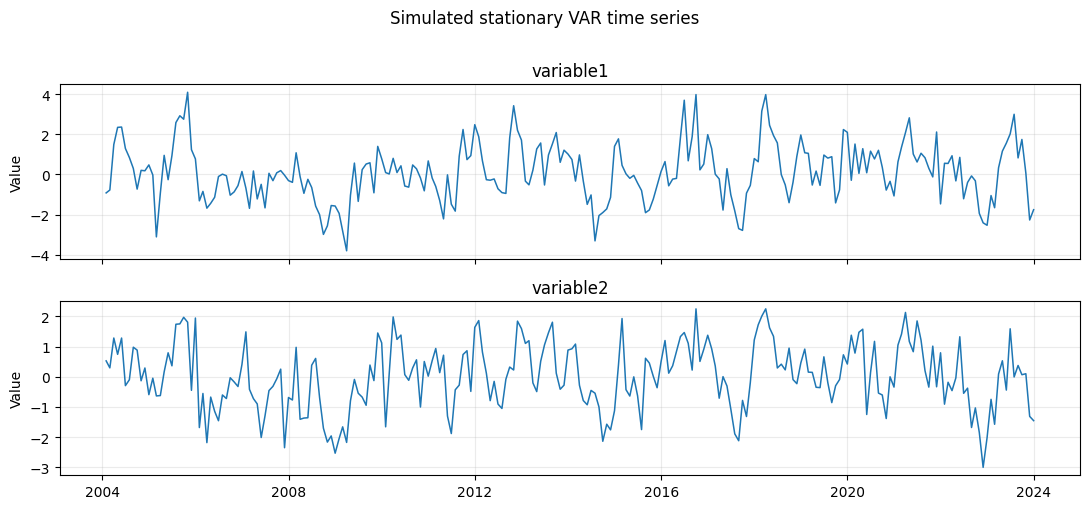


Lag-order selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      0.3611      0.3907       1.435      0.3730
1    -0.2922*    -0.2036*     0.7466*    -0.2565*
2     -0.2657     -0.1180      0.7667     -0.2061
3     -0.2419    -0.03514      0.7852     -0.1585
4     -0.2265     0.03928      0.7974     -0.1193
5     -0.2460     0.07891      0.7821     -0.1150
6     -0.2371      0.1468      0.7891    -0.08229
-------------------------------------------------
Chosen VAR lag (AIC, min 1): 1
Estimated VAR is stable: True
Residual whiteness test p-value: 0.4950


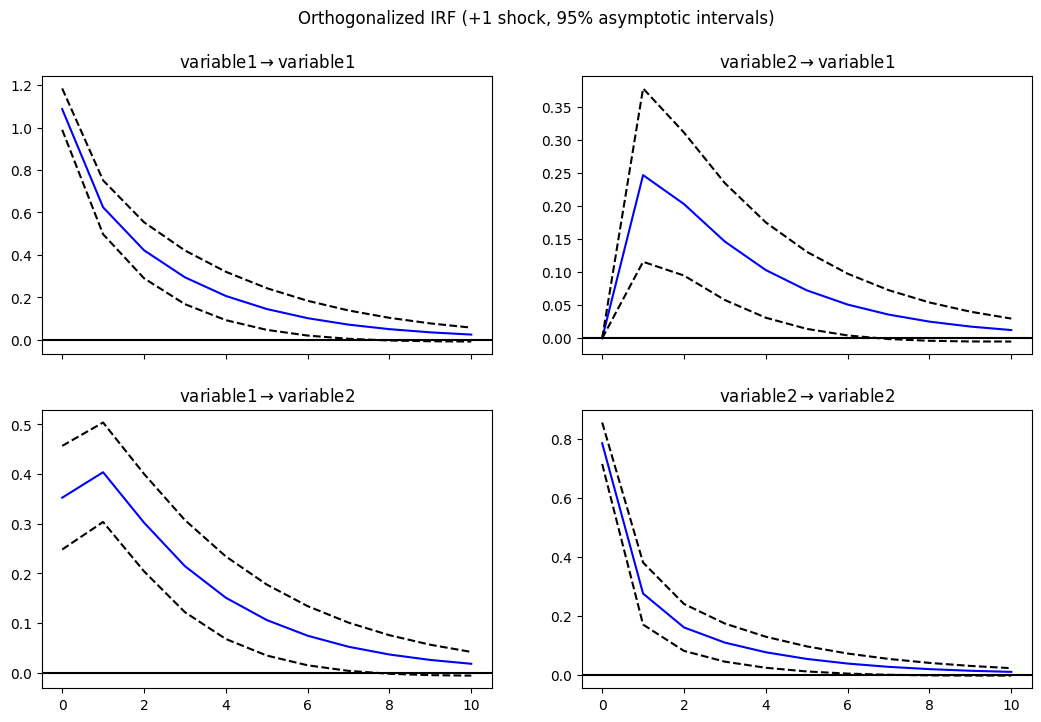

IRF array shape (horizon + 1, response, impulse): (11, 2, 2)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# -----------------------------------------------------------------------------
# 1. 재현 가능한 2변수 교육용 시계열 생성
#    독립 백색잡음만 사용하면 실제 충격 전파를 설명하기 어렵습니다.
#    아래는 서로 시차 영향을 주고받는 안정적인 VAR(1) 생성과정입니다.
#    y_t = A y_(t-1) + u_t  (|A의 고유값| < 1 이면 안정적)
# -----------------------------------------------------------------------------
rng = np.random.default_rng(42)
n_obs, burn_in = 240, 100
A = np.array([[0.55, 0.18],
              [0.25, 0.40]])  # 행=반응변수, 열=한 시점 전의 설명변수
cov_u = np.array([[1.0, 0.35], [0.35, 0.8]])  # 동시적 오차 상관
u = rng.multivariate_normal([0.0, 0.0], cov_u, size=n_obs + burn_in)
y = np.zeros((n_obs + burn_in, 2), dtype=float)
for t in range(1, len(y)):
    y[t] = A @ y[t-1] + u[t]

# 초기값의 영향을 줄이기 위해 burn-in 100개를 제외합니다.
dates = pd.date_range('2004-01-31', periods=n_obs, freq='ME')
df = pd.DataFrame(y[burn_in:], index=dates, columns=['variable1', 'variable2'])
print('Observations:', len(df))
print('Simulation VAR(1) eigenvalue magnitudes:', np.round(np.abs(np.linalg.eigvals(A)), 3))

# -----------------------------------------------------------------------------
# 2. 데이터와 정상성(ADF) 점검
#    ADF p값만으로 정상성을 확정하지는 않으며, 추세/구조변화도 함께 확인해야 합니다.
# -----------------------------------------------------------------------------
print('\nADF stationarity diagnostics (H0: unit root)')
for col in df.columns:
    stat, pvalue, *_ = adfuller(df[col], autolag='AIC')
    print(f'{col}: ADF={stat:.3f}, p-value={pvalue:.4g}')

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], linewidth=1.1)
    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.grid(alpha=0.25)
fig.suptitle('Simulated stationary VAR time series', y=1.01)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. VAR 시차 선택 및 적합
#    AIC는 모델 선정의 한 예시이며, 진단과 연구 목적도 함께 고려합니다.
#    테스트 데이터 성능을 최적화하는 실습이 아니라 전체 자료를 이용한
#    '사후적 동학 해석' 실습입니다.
# -----------------------------------------------------------------------------
var_model = VAR(df)
order_selection = var_model.select_order(maxlags=6)
print('\nLag-order selection:')
print(order_selection.summary())
selected_lag = order_selection.selected_orders['aic']
if selected_lag is None or selected_lag < 1:
    # IRF 강의에서는 0차 자기회귀가 아닌 동적 VAR을 사용합니다.
    # 이 교육용 자료는 실제 VAR(1)에서 생성되었으므로 최소 1차를 사용합니다.
    selected_lag = 1
results = var_model.fit(selected_lag, trend='c')
print(f'Chosen VAR lag (AIC, min 1): {selected_lag}')
print('Estimated VAR is stable:', results.is_stable(verbose=False))
if not results.is_stable(verbose=False):
    raise ValueError('Unstable VAR: IRF interpretation needs further examination.')

# 잔차 자기상관이 남는지 점검합니다. 유의하면 시차 재검토가 필요합니다.
try:
    whiteness = results.test_whiteness(nlags=max(12, selected_lag + 1))
    print(f'Residual whiteness test p-value: {whiteness.pvalue:.4f}')
except (ValueError, RuntimeError) as exc:
    print('Residual whiteness diagnostic unavailable:', exc)

# -----------------------------------------------------------------------------
# 4. IRF: 행은 반응변수(response), 열은 충격변수(impulse)
#    직교화(Cholesky) IRF는 변수 순서를 가정한 분석입니다.
#    예측지평 h=0~10에서 +1 직교화 충격에 대한 반응을 나타냅니다.
# -----------------------------------------------------------------------------
horizon = 10
irf = results.irf(horizon)
fig = irf.plot(orth=True, signif=0.05, stderr_type='asym', figsize=(11, 7))
fig.suptitle('Orthogonalized IRF (+1 shock, 95% asymptotic intervals)', y=1.02)
plt.show()
print('IRF array shape (horizon + 1, response, impulse):', irf.orth_irfs.shape)


## 양(+)의 충격과 음(-)의 충격: 정확한 해석

- **양의 충격(Positive shock)**: 특정 충격 변수에 **+1 단위의 예기치 않은 변화**를 가한 경우입니다. 예를 들어 원유가격의 양의 충격은 가격이 예상보다 상승한 것을 뜻하지, 경제적으로 반드시 좋은 사건을 뜻하지는 않습니다.
- **음의 충격(Negative shock)**: 동일한 충격 변수에 **-1 단위의 예기치 않은 변화**를 가한 경우입니다.
- **선형 VAR**에서 다른 조건이 같으면 충격의 부호를 뒤집었을 때 반응도 정확히 반대 부호가 됩니다. 이를 비대칭 효과의 증거로 해석해서는 안 됩니다.
- **해석 주의:** 아래 실습의 `orth_irfs[h, response, impulse]`는 **첫 번째 차원이 시점, 두 번째가 반응변수, 세 번째가 충격변수**입니다. 원본에서는 이 축을 거꾸로 표기한 문제가 있었습니다.
- **식별 주의:** 직교화 IRF(`orth=True`)는 Cholesky 순서에 영향을 받습니다. 동일한 조건의 양·음 충격 비교를 위해 **둘 다 직교화 IRF를 사용**합니다. 원본의 비직교·직교 IRF 혼용을 교정했습니다.

### 관련 수식

VAR(p) 모형:

$$
Y_t=c+A_1Y_{t-1}+\cdots+A_pY_{t-p}+u_t
$$

선형 모형의 대칭성:

$$
IRF_h(-\delta)=-IRF_h(+\delta)
$$

**결과 해석:** 충격반응함수는 *모형과 충격 식별 가정에 따른 동적 반응*입니다. 통계적 연관성을 인과효과로 해석하려면 추가적인 식별 전략이 필요합니다.


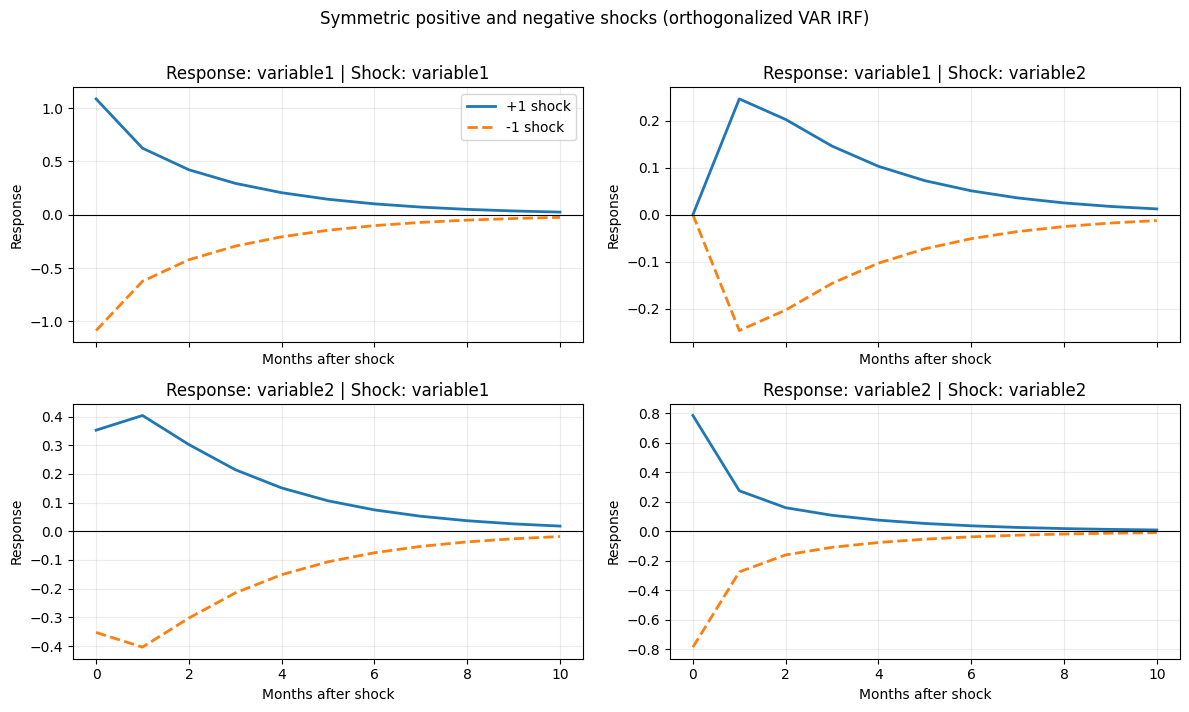

Max numerical asymmetry check: 0.0
Reminder: these curves are from simulated data, not identified causal effects.


In [2]:
# -----------------------------------------------------------------------------
# 실습 2. 동일한 직교화(Cholesky) 가정하에서 양/음 충격 비교
# 앞 셀에서 적합한 results, df, horizon, irf를 그대로 사용합니다.
# -----------------------------------------------------------------------------
if 'irf' not in globals() or 'df' not in globals():
    raise RuntimeError('먼저 위의 VAR 적합 및 IRF 실습 셀을 실행하세요.')

# orth_irfs의 shape = (horizon + 1, response index, impulse index)
positive = irf.orth_irfs
negative = -positive  # 선형 VAR이므로 -1 충격의 반응은 +1 충격의 정확한 음수

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
steps = np.arange(positive.shape[0])
for response_idx, response_name in enumerate(df.columns):
    for impulse_idx, impulse_name in enumerate(df.columns):
        ax = axes[response_idx, impulse_idx]
        ax.plot(steps, positive[:, response_idx, impulse_idx],
                label='+1 shock', linewidth=2)
        ax.plot(steps, negative[:, response_idx, impulse_idx],
                label='-1 shock', linewidth=2, linestyle='--')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f'Response: {response_name} | Shock: {impulse_name}')
        ax.set_xlabel('Months after shock')
        ax.set_ylabel('Response')
        ax.grid(alpha=0.25)
        if response_idx == 0 and impulse_idx == 0:
            ax.legend()
fig.suptitle('Symmetric positive and negative shocks (orthogonalized VAR IRF)', y=1.01)
plt.tight_layout()
plt.show()

# 참고: IRF(h=0)은 동시 충격반응이며, h>=1은 충격 후 동태적 반응입니다.
# 참고: 신뢰구간은 위의 첫 번째 IRF 그래프에 표시됩니다.
# 참고: 변수 순서를 바꾸면 Cholesky 직교화 결과가 달라질 수 있습니다.
print('Max numerical asymmetry check:', np.max(np.abs(positive + negative)))
print('Reminder: these curves are from simulated data, not identified causal effects.')
